In [1]:
import pandas as pd

df = pd.read_csv("f1_results.csv")
df2 = pd.read_csv("f1_driver_standings.csv")

In [2]:
df_2026 = pd.read_csv("2026results.csv")
df_2026.drop(columns=['Unnamed: 0'], inplace=True)
df = df[~df['season'].isin([2026])]
df = pd.concat([df, df_2026], ignore_index=True, axis=0)

In [3]:
current_season = df2['season'].max()

seasons_to_analyze = range(current_season, max(1950, current_season - 40), -1)

print(f"Analyzing features for seasons: {list(seasons_to_analyze)}")

all_seasons_features_list = []
till_round = 11

for season in seasons_to_analyze:
        
    # Filter race results up to round till_round for the current season
    season_races_till_round = df[(df['season'] == season) & (df['round'] <= till_round)].copy()

    # Get unique drivers who participated in the first till_round races of this season
    active_drivers_in_season_till_round = season_races_till_round['driver_id'].unique()

    if len(active_drivers_in_season_till_round) == 0:
        print(f"No race data for season {season} up to round {till_round}. Skipping.")
        continue

    temp_season_features = pd.DataFrame({'driver_id': active_drivers_in_season_till_round})
    temp_season_features['season'] = season

    # Add driver names 
    driver_names_map = season_races_till_round[['driver_id', 'driver_name']].drop_duplicates().set_index('driver_id')['driver_name']
    temp_season_features['driver_name'] = temp_season_features['driver_id'].map(driver_names_map)

    # --- Calculate current season features (after till_round races) ---

    # position after till_round races
    points_after_till_round_races = season_races_till_round.groupby('driver_id')['points'].sum().reset_index()
    points_after_till_round_races = points_after_till_round_races.sort_values(by='points', ascending=False).reset_index(drop=True)
    points_after_till_round_races['current_season_position_after_N_races'] = points_after_till_round_races.index + 1
    temp_season_features = temp_season_features.merge(points_after_till_round_races[['driver_id', 'current_season_position_after_N_races']], on='driver_id', how='left')

    # wins so far
    wins_after_till_round_races = season_races_till_round[season_races_till_round['position'] == 1].groupby('driver_id').size().reset_index(name='wins')
    temp_season_features = temp_season_features.merge(wins_after_till_round_races, on='driver_id', how='left').fillna({'wins': 0})

    # avg grid position
    avg_grid_after_till_round_races = season_races_till_round.groupby('driver_id')['grid'].mean().reset_index(name='avg_grid_position')
    temp_season_features = temp_season_features.merge(avg_grid_after_till_round_races, on='driver_id', how='left')

    # avg points
    avg_points_after_till_round_races = season_races_till_round.groupby('driver_id')['points'].mean().reset_index(name='avg_points')
    temp_season_features = temp_season_features.merge(avg_points_after_till_round_races, on='driver_id', how='left')

    # --- Calculate historical features (full previous seasons) ---

    # last_season_finish
    last_season = season - 1
    last_season_finish_data = df2[df2['season'] == last_season][['driver_id', 'position']].rename(columns={'position': 'last_season_finish'})
    temp_season_features = temp_season_features.merge(last_season_finish_data, on='driver_id', how='left')

    # avg_finish_last_N_seasons (for N=2 to 5)
    for n in range(2, 6):
        historical_seasons_for_avg = range(season - n, season) # Seasons from (current-n) to (current-1)
        hist_avg_finish = df2[df2['season'].isin(historical_seasons_for_avg)].groupby('driver_id')['position'].mean().reset_index()
        hist_avg_finish = hist_avg_finish.rename(columns={'position': f'avg_finish_last_{n}_seasons'})
        temp_season_features = temp_season_features.merge(hist_avg_finish, on='driver_id', how='left')

    all_seasons_features_list.append(temp_season_features)

# Concatenate all season features into a single DataFrame
multi_season_driver_features = pd.concat(all_seasons_features_list, ignore_index=True)

# Display the final features DataFrame
print(f"\nFeatures for the last 10 seasons (up to round {till_round}):")
display(multi_season_driver_features.head(10))
print("\nDataFrame Info:")
display(multi_season_driver_features.info())

Analyzing features for seasons: [2026, 2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002, 2001, 2000, 1999, 1998, 1997, 1996, 1995, 1994, 1993, 1992, 1991, 1990, 1989, 1988, 1987]

Features for the last 10 seasons (up to round 11):


,driver_id,season,driver_name,current_season_position_after_N_races,wins,avg_grid_position,avg_points,last_season_finish,avg_finish_last_2_seasons,avg_finish_last_3_seasons,avg_finish_last_4_seasons,avg_finish_last_5_seasons
0,russell,2026,George Russell,3,2.0,2.909091,12.181818,4.0,5.0,6.000000,5.50,7.4
1,antonelli,2026,Andrea Kimi Antonelli,1,6.0,2.181818,18.000000,7.0,7.0,7.000000,7.00,7.0
2,leclerc,2026,Charles Leclerc,4,1.0,4.272727,10.636364,5.0,4.0,4.333333,3.75,4.4
3,hamilton,2026,Lewis Hamilton,2,1.0,4.363636,13.727273,6.0,6.5,5.333333,5.50,4.8
4,norris,2026,Lando Norris,5,1.0,5.636364,9.272727,1.0,1.5,3.000000,4.00,4.4
5,max_verstappen,2026,Max Verstappen,6,0.0,6.545455,9.090909,2.0,1.5,1.333333,1.25,1.2
6,bearman,2026,Oliver Bearman,13,0.0,14.454545,1.545455,13.0,15.5,15.500000,15.50,15.5
7,arvid_lindblad,2026,Arvid Lindblad,11,0.0,10.909091,2.000000,NaN,NaN,NaN,NaN,NaN
8,bortoleto,2026,Gabriel Bortoleto,14,0.0,12.909091,0.909091,19.0,19.0,19.000000,19.00,19.0
9,gasly,2026,Pierre Gasly,9,0.0,11.090909,3.727273,18.0,14.0,13.000000,13.25,12.4



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   driver_id                              1001 non-null   object 
 1   season                                 1001 non-null   int64  
 2   driver_name                            1001 non-null   object 
 3   current_season_position_after_N_races  1001 non-null   int64  
 4   wins                                   1001 non-null   float64
 5   avg_grid_position                      1001 non-null   float64
 6   avg_points                             1001 non-null   float64
 7   last_season_finish                     689 non-null    float64
 8   avg_finish_last_2_seasons              746 non-null    float64
 9   avg_finish_last_3_seasons              766 non-null    float64
 10  avg_finish_last_4_seasons              775 non-null    

None

In [4]:
# Merge with df2 to get the actual final position for each season
final_positions = df2[['season', 'driver_id', 'position']].rename(columns={'position': 'final_position'})
multi_season_driver_features = multi_season_driver_features.merge(final_positions, on=['season', 'driver_id'], how='left')

print("DataFrame with Target Variable:")
display(multi_season_driver_features.head())
display(multi_season_driver_features.info())

DataFrame with Target Variable:


,driver_id,season,driver_name,current_season_position_after_N_races,wins,avg_grid_position,avg_points,last_season_finish,avg_finish_last_2_seasons,avg_finish_last_3_seasons,avg_finish_last_4_seasons,avg_finish_last_5_seasons,final_position
0,russell,2026,George Russell,3,2.0,2.909091,12.181818,4.0,5.0,6.000000,5.50,7.4,2.0
1,antonelli,2026,Andrea Kimi Antonelli,1,6.0,2.181818,18.000000,7.0,7.0,7.000000,7.00,7.0,1.0
2,leclerc,2026,Charles Leclerc,4,1.0,4.272727,10.636364,5.0,4.0,4.333333,3.75,4.4,3.0
3,hamilton,2026,Lewis Hamilton,2,1.0,4.363636,13.727273,6.0,6.5,5.333333,5.50,4.8,4.0
4,norris,2026,Lando Norris,5,1.0,5.636364,9.272727,1.0,1.5,3.000000,4.00,4.4,5.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 13 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   driver_id                              1001 non-null   object 
 1   season                                 1001 non-null   int64  
 2   driver_name                            1001 non-null   object 
 3   current_season_position_after_N_races  1001 non-null   int64  
 4   wins                                   1001 non-null   float64
 5   avg_grid_position                      1001 non-null   float64
 6   avg_points                             1001 non-null   float64
 7   last_season_finish                     689 non-null    float64
 8   avg_finish_last_2_seasons              746 non-null    float64
 9   avg_finish_last_3_seasons              766 non-null    float64
 10  avg_finish_last_4_seasons              775 non-null    float64
 11  avg_

None

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

data = multi_season_driver_features.dropna(subset=['final_position']).copy()

# 'current_season_position_after_N_races' is highly correlated with the target,
# let's exclude it for a more challenging prediction, or consider using it as a feature.
# For now, let's exclude direct 'position' related features that are too close to the target.

feature_columns = [
    'wins',
    'avg_grid_position',
    'avg_points',
    'last_season_finish',
    'avg_finish_last_2_seasons',
    'avg_finish_last_3_seasons',
    'avg_finish_last_4_seasons',
    'avg_finish_last_5_seasons'
]

# Fill NaN values in features. Using 0 for simplicity, needs to be modified since it doesn't make sense for positions
data[feature_columns] = data[feature_columns].fillna(0)

X = data[feature_columns]
y = data['final_position']

# Time-based split for training, evaluation, and 2026 prediction (80-20 ratio for train/eval)

seasons_for_train_eval = sorted(data[data['season'] != current_season]['season'].unique())

num_total_train_eval_seasons = len(seasons_for_train_eval)
num_train_seasons = round(0.8 * num_total_train_eval_seasons)

# Determine the cutoff year for the training set
# The training set will include seasons up to and including this year
train_seasons_cutoff_year = seasons_for_train_eval[num_train_seasons - 1]

print(f"Total seasons for train/eval (excluding {current_season}): {num_total_train_eval_seasons}")
print(f"Number of seasons for training: {num_train_seasons}")
print(f"Training seasons will include up to year: {train_seasons_cutoff_year}")

X_train = X[data['season'] <= train_seasons_cutoff_year]
y_train = y[data['season'] <= train_seasons_cutoff_year]

X_eval = X[(data['season'] > train_seasons_cutoff_year) & (data['season'] != current_season)]
y_eval = y[(data['season'] > train_seasons_cutoff_year) & (data['season'] != current_season)]

X_predict_2026 = X[data['season'] == current_season]
y_predict_2026_actual = y[data['season'] == current_season] # This is the dataset's projection

print(f"Training data shape: {X_train.shape}")
print(f"Evaluation data shape: {X_eval.shape}")
print(f"2026 Prediction data shape: {X_predict_2026.shape}")

Total seasons for train/eval (excluding 2026): 39
Number of seasons for training: 31
Training seasons will include up to year: 2017
Training data shape: (658, 8)
Evaluation data shape: (165, 8)
2026 Prediction data shape: (22, 8)


C:\Users\karan\AppData\Local\Temp\ipykernel_2348\2645127565.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI', y='Feature', data=mi_df, palette='viridis')


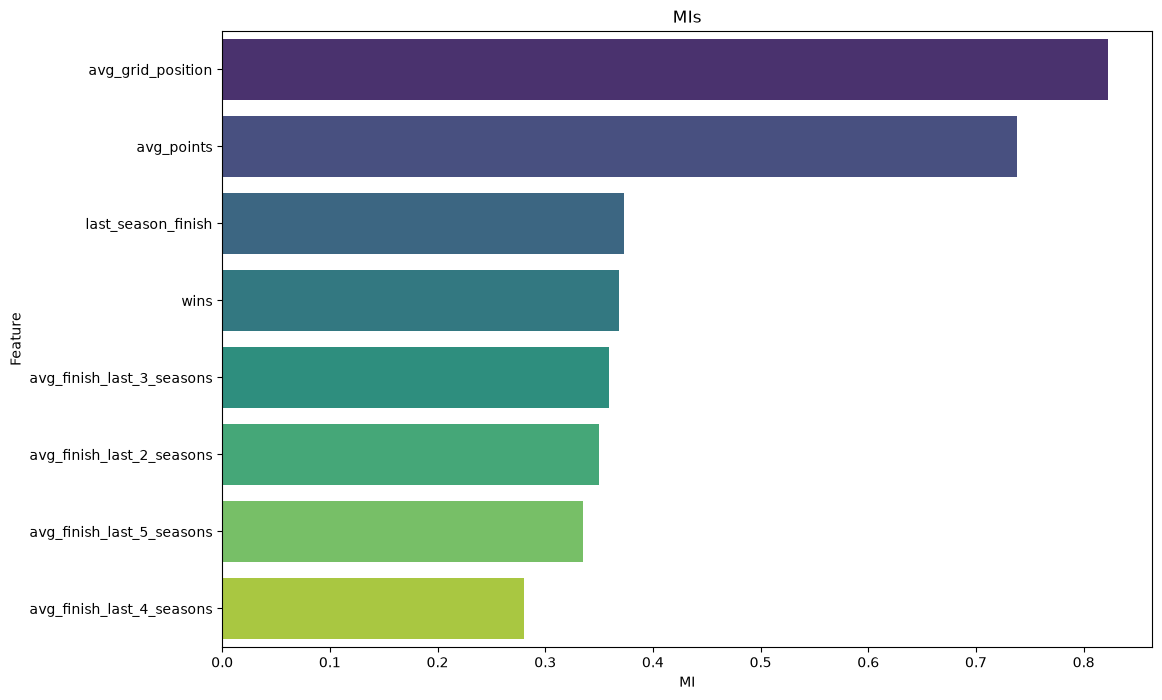

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
import numpy as np

mis = mutual_info_regression(X_train, y_train)

mi_df = pd.DataFrame({'Feature': np.array(feature_columns), 'MI': np.array(mis)})
mi_df = mi_df.sort_values(by='MI', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='MI', y='Feature', data=mi_df, palette='viridis')
plt.title('MIs')
plt.xlabel('MI')
plt.ylabel('Feature')
plt.savefig("mi.png", bbox_inches='tight')
plt.show()

In [7]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_eval)
mae = mean_absolute_error(y_eval, y_pred)
r2 = r2_score(y_eval, y_pred)

print(f"\nEvaluation using (Actual Historical Data):")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")


Evaluation using (Actual Historical Data):
Mean Absolute Error (MAE): 1.60
R-squared (R2): 0.86


### Feature Importances


Feature Importances from RandomForestRegressor:


,Feature,Importance
1,avg_grid_position,0.681022
2,avg_points,0.229124
0,wins,0.017821
4,avg_finish_last_2_seasons,0.015243
7,avg_finish_last_5_seasons,0.014666
5,avg_finish_last_3_seasons,0.014355
6,avg_finish_last_4_seasons,0.013961
3,last_season_finish,0.013807


C:\Users\karan\AppData\Local\Temp\ipykernel_2348\3139056256.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


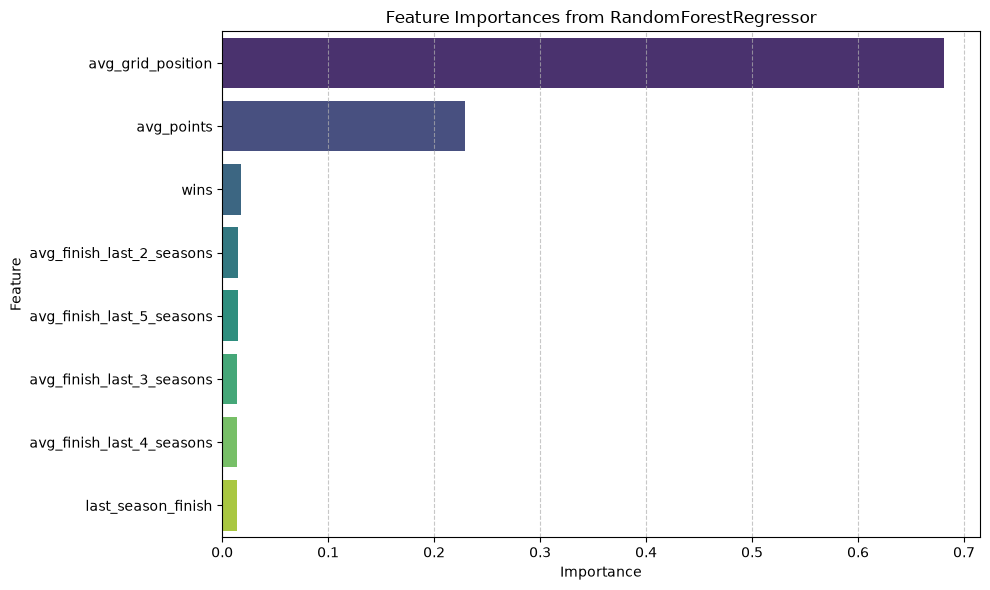

In [8]:
feature_importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': feature_importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importances from RandomForestRegressor:")
display(feature_importance_df)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importances from RandomForestRegressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Final predictions for 2026 season

In [9]:
y_pred_2026 = model.predict(X_predict_2026)

predictions_2026_info = multi_season_driver_features[
    (multi_season_driver_features['season'] == current_season)][['driver_id', 'driver_name', 'current_season_position_after_N_races']
].set_index(X_predict_2026.index)

predictions_2026_df = pd.DataFrame({
    'Raw_Predicted_Position_2026': y_pred_2026,
    'Current_Position_2026': y_predict_2026_actual.astype(int)
})

predictions_2026_df = predictions_2026_df.merge(predictions_2026_info, left_index=True, right_index=True)

# Sort by raw predicted position and assign ranks from 1 to N
predictions_2026_df = predictions_2026_df.sort_values(by='Raw_Predicted_Position_2026').reset_index(drop=True)
predictions_2026_df['Predicted_Ranked_Position_2026'] = predictions_2026_df.index + 1

print(f"\nPredicted Final Positions for {current_season} Season (Based on dataset's early season data):")
display(predictions_2026_df[['driver_name', 'Predicted_Ranked_Position_2026', 'Raw_Predicted_Position_2026', 'Current_Position_2026']])


Predicted Final Positions for 2026 Season (Based on dataset's early season data):


,driver_name,Predicted_Ranked_Position_2026,Raw_Predicted_Position_2026,Current_Position_2026
0,Andrea Kimi Antonelli,1,1.12,1
1,George Russell,2,3.29,2
2,Lando Norris,3,3.52,5
3,Charles Leclerc,4,3.64,3
4,Lewis Hamilton,5,3.71,4
5,Oscar Piastri,6,3.92,6
6,Max Verstappen,7,5.12,9
7,Arvid Lindblad,8,8.61,11
8,Isack Hadjar,9,9.20,12
9,Pierre Gasly,10,9.37,8


In [10]:
drivers_active_2026 = df[df['season'] == 2026]['driver_id'].unique()

# Filter the original df to include all races for drivers active from 2010 onwards
df_active_2026_all_races = df[df['driver_id'].isin(drivers_active_2026)].copy()

# Calculate the difference between grid position and final position
df_active_2026_all_races['grid_vs_result_diff'] = df_active_2026_all_races['grid'] - df_active_2026_all_races['position']

# Group by driver and calculate the average difference and count of races
avg_diff_by_driver = df_active_2026_all_races.groupby(['driver_id', 'driver_name']).agg(
    grid_vs_result_diff=('grid_vs_result_diff', 'mean'),
    number_of_races=('grid_vs_result_diff', 'count')
).reset_index()

avg_diff_by_driver = avg_diff_by_driver[avg_diff_by_driver['number_of_races'] > 50]

top_losers = avg_diff_by_driver.sort_values(by='grid_vs_result_diff', ascending=True)

C:\Users\karan\AppData\Local\Temp\ipykernel_2348\4256592027.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='grid_vs_result_diff', y='driver_name', data=top_losers, palette='viridis')


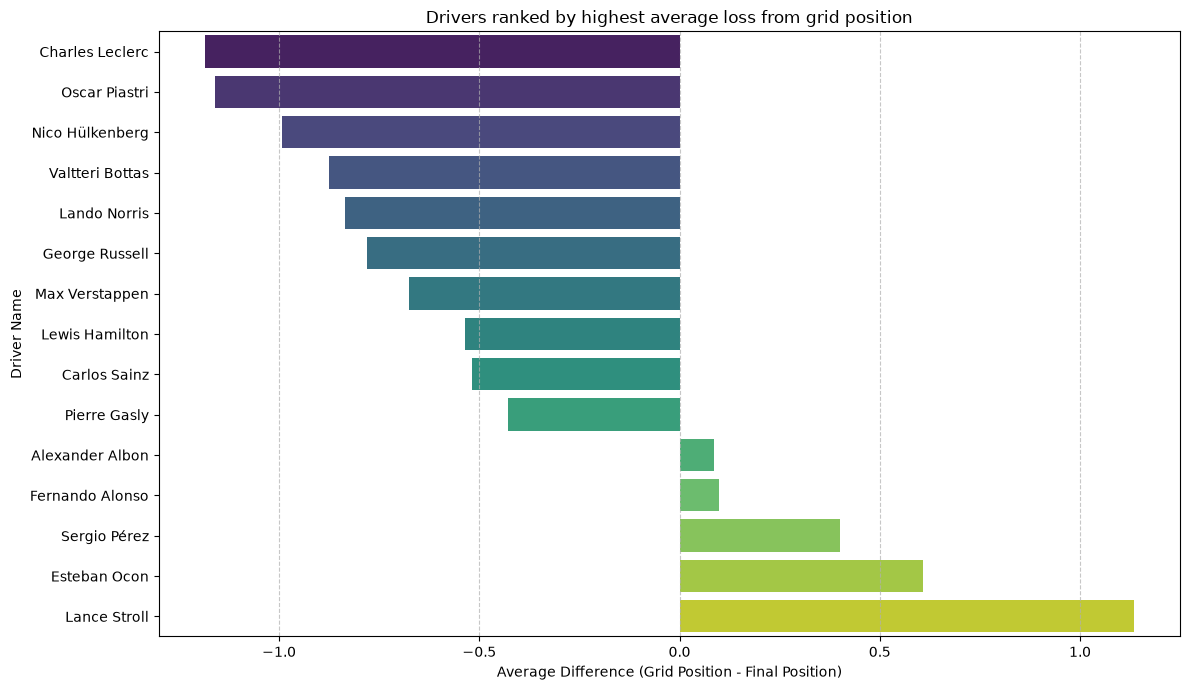

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='grid_vs_result_diff', y='driver_name', data=top_losers, palette='viridis')
plt.title('Drivers ranked by highest average loss from grid position')
plt.xlabel('Average Difference (Grid Position - Final Position)')
plt.ylabel('Driver Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()